<a href="https://colab.research.google.com/github/francji1/01NAEX/blob/main/code/01NAEX_Ex01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01NAEX - Exercise 01: Simple comparative experiments

Data and exercises come from D. C. Montgomery: *Design and Analysis of Experiments*, 8th edition, Chapter 2.
Problem numbers follow the 8th edition.

## Learning goals

* Compare two treatments with the two-sample $t$-test (pooled and Welch) and interpret the $p$-value and the confidence interval.
* Test the equality of two variances with the $F$-test.
* Check the normality assumption (kernel density estimate, normal probability plot, Shapiro-Wilk test).
* Compute the power of a test and the sample size needed to reach a given power.


## Setup

In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, t, f, shapiro
from statsmodels.stats.power import TTestIndPower
import statsmodels.api as sm

## Example from the lecture: Portland cement mortar

Lecture 1 compared the tension bond strength of a modified and an unmodified mortar formulation
(Montgomery, Example 2.1). We repeat the analysis in Python: $F$-test for the variances, two-sample $t$-tests,
confidence intervals, normality checks, and the power of the test.

In [115]:
# Data arrays
y1 = np.array([16.85,16.40,17.21,16.35,16.52,17.04,16.96,17.15,16.59,16.57])  # Modified Mortar
y2 = np.array([16.62,16.75,17.37,17.12,16.98,16.87,17.34,17.02,17.08,17.27])  # Unmodified Mortar

# Sample variances
s1_squared = np.var(y1, ddof=1)
s2_squared = np.var(y2, ddof=1)

# Degrees of freedom
dfn = len(y1) - 1  # Degrees of freedom numerator
dfd = len(y2) - 1  # Degrees of freedom denominator

# F-test statistic
F = s1_squared / s2_squared

# Two-tailed p-value
p_value = 2 * min(f.cdf(F, dfn, dfd), 1 - f.cdf(F, dfn, dfd))

print('F-statistic:', F)
print('Degrees of freedom:', dfn, 'and', dfd)
print('p-value:', p_value)

F-statistic: 1.6292573577265188
Degrees of freedom: 9 and 9
p-value: 0.47846033941944155


In [116]:
# 1. Two-sample t-test assuming equal variances (pooled; var.equal = TRUE in R)
t_stat_equal_var, p_value_equal_var = stats.ttest_ind(y1, y2, equal_var=True)

# Calculate confidence interval for equal variance
n1, n2 = len(y1), len(y2)
mean_diff = np.mean(y1) - np.mean(y2)
pooled_std = np.sqrt(((n1 - 1) * np.var(y1, ddof=1) + (n2 - 1) * np.var(y2, ddof=1)) / (n1 + n2 - 2))
se_pooled = pooled_std * np.sqrt(1/n1 + 1/n2)
conf_interval_equal_var = stats.t.interval(0.95, df=n1 + n2 - 2, loc=mean_diff, scale=se_pooled)

# 2. Welch's t-test (var.equal = FALSE in R)
t_stat_unequal_var, p_value_unequal_var = stats.ttest_ind(y1, y2, equal_var=False)
df_unequal_var = ((np.var(y1, ddof=1)/n1 + np.var(y2, ddof=1)/n2)**2) / \
                 ((np.var(y1, ddof=1)/n1)**2/(n1-1) + (np.var(y2, ddof=1)/n2)**2/(n2-1))

# Calculate confidence interval for unequal variance
se_unequal = np.sqrt(np.var(y1, ddof=1)/n1 + np.var(y2, ddof=1)/n2)
conf_interval_unequal_var = stats.t.interval(0.95, df=df_unequal_var, loc=mean_diff, scale=se_unequal)

# Results for t-test assuming equal variances
print("Two-Sample T-Test Assuming Equal Variances")
print(f"t-statistic: {t_stat_equal_var}")
print(f"p-value: {p_value_equal_var}")
print(f"95% confidence interval: {conf_interval_equal_var}")
print(f"Mean of y1: {np.mean(y1)}, Mean of y2: {np.mean(y2)}")
print()

# Results for Welch's t-test (unequal variances)
print("Welch's Two-Sample T-Test (Assuming Unequal Variances)")
print(f"t-statistic: {t_stat_unequal_var}")
print(f"p-value: {p_value_unequal_var}")
print(f"Degrees of freedom: {df_unequal_var}")
print(f"95% confidence interval: {conf_interval_unequal_var}")
print(f"Mean of y1: {np.mean(y1)}, Mean of y2: {np.mean(y2)}")


Two-Sample T-Test Assuming Equal Variances
t-statistic: -2.1868757949582633
p-value: 0.0421967159248899
95% confidence interval: (np.float64(-0.5450733877678422), np.float64(-0.010926612232162292))
Mean of y1: 16.764000000000003, Mean of y2: 17.042000000000005

Welch's Two-Sample T-Test (Assuming Unequal Variances)
t-statistic: -2.1868757949582633
p-value: 0.042998380088903033
Degrees of freedom: 17.02484516235282
95% confidence interval: (np.float64(-0.5461741394750226), np.float64(-0.009825860524981911))
Mean of y1: 16.764000000000003, Mean of y2: 17.042000000000005


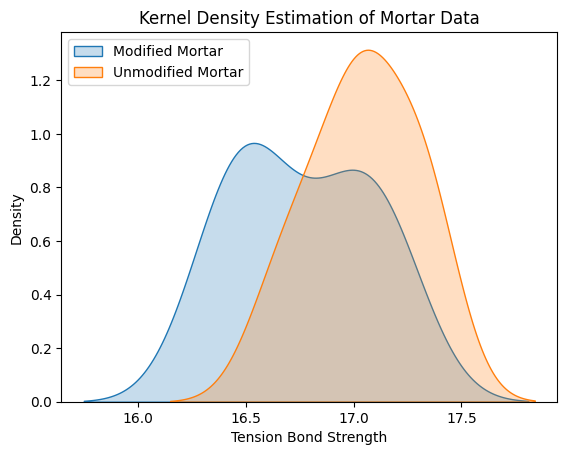

In [117]:
# Kernel Density Plot
sns.kdeplot(y1, fill=True, label='Modified Mortar')
sns.kdeplot(y2, fill=True, label='Unmodified Mortar')
plt.title('Kernel Density Estimation of Mortar Data')
plt.xlabel('Tension Bond Strength')
plt.legend()
plt.show()

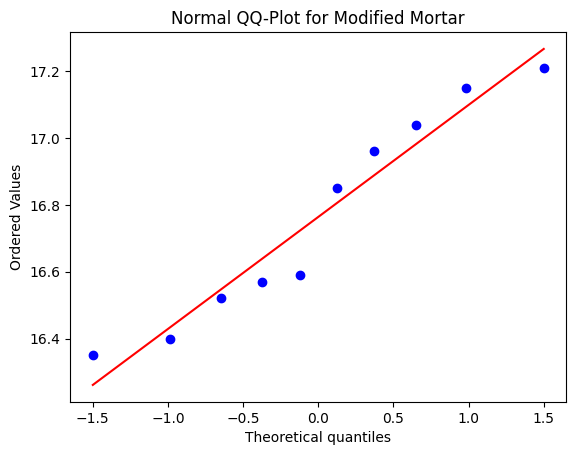

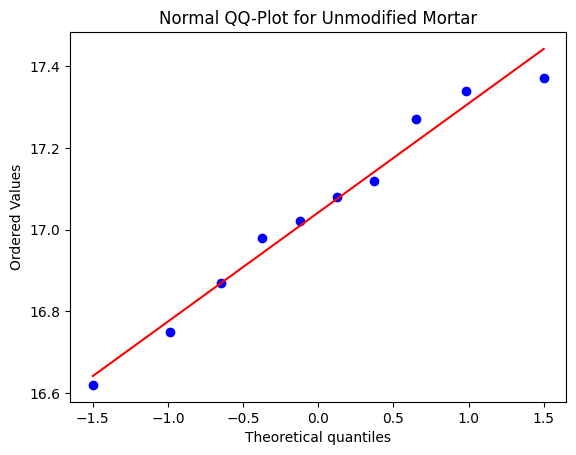

In [118]:
# QQ-Plot for y1
plt.figure()
stats.probplot(y1, dist="norm", plot=plt)
plt.title('Normal QQ-Plot for Modified Mortar')
plt.show()

# QQ-Plot for y2
plt.figure()
stats.probplot(y2, dist="norm", plot=plt)
plt.title('Normal QQ-Plot for Unmodified Mortar')
plt.show()

In [119]:
# Shapiro-Wilk test for y1
statistic_y1, p_value_y1 = shapiro(y1)
print(f'Shapiro-Wilk Test for y1: Statistic={statistic_y1}, p-value={p_value_y1}')

# Shapiro-Wilk test for y2
statistic_y2, p_value_y2 = shapiro(y2)
print(f'Shapiro-Wilk Test for y2: Statistic={statistic_y2}, p-value={p_value_y2}')

Shapiro-Wilk Test for y1: Statistic=0.9186332801846344, p-value=0.3456968630049325
Shapiro-Wilk Test for y2: Statistic=0.9626192871584892, p-value=0.8152773063551302


In [120]:
# Parameters
effect_size = (np.mean(y1) - np.mean(y2)) / np.sqrt((s1_squared + s2_squared) / 2)
alpha = 0.05
power = 0.95

# Create an instance of the power analysis class
analysis = TTestIndPower()

# Calculate required sample size
sample_size = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, alternative='two-sided')
print(f'Required sample size per group: {np.ceil(sample_size)}')

# Calculate power of the test with n=10
actual_power = analysis.power(effect_size=effect_size, nobs1=10, alpha=alpha, alternative='two-sided')
print(f'Power of the test with n=10 per group: {actual_power}')

Required sample size per group: 29.0
Power of the test with n=10 per group: 0.543644227812653


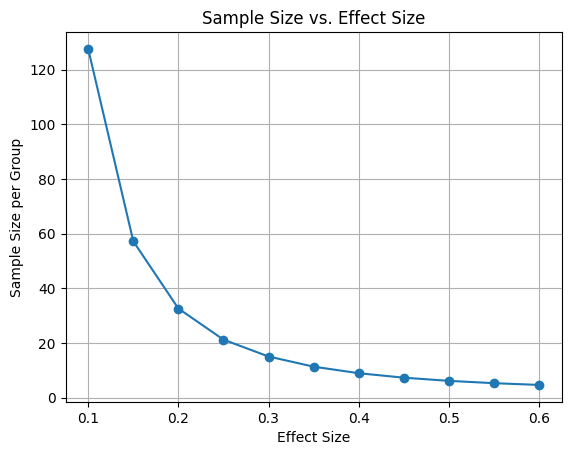

In [121]:
# Parameters
alpha = 0.05
power = 0.80
sd = 0.284  # Standard deviation
effect_sizes = np.array([0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6])

# Calculate sample sizes
analysis = TTestIndPower()
sample_sizes = []
for delta in effect_sizes:
    effect_size = delta / sd
    n = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, alternative='two-sided')
    sample_sizes.append(n)

# Plotting
plt.plot(effect_sizes, sample_sizes, marker='o')
plt.xlabel('Effect Size')
plt.ylabel('Sample Size per Group')
plt.title('Sample Size vs. Effect Size')
plt.grid(True)
plt.show()


## Assignment

* Run the notebook above and get familiar with Python.
* Solve the following problems from Montgomery, *Design and Analysis of Experiments* (8th edition). Start in class and finish at home.
* Submit your solved notebook as a pull request into the `HW/` folder of the course repository, named
  `HW/01NAEX_Ex01_HW_<Surname>.ipynb` (see `HW/README.md`).
  **Deadline: Sunday 4 October 2026** (the next lecture is on 5 October; 28 September is a public holiday).

### Exercise 2.20

The shelf life of a carbonated beverage is of interest. Ten bottles are randomly selected and tested,
and the following results (in days) are obtained:

| | | | | |
|---|---|---|---|---|
| 108 | 124 | 124 | 106 | 115 |
| 138 | 163 | 159 | 134 | 139 |

* We would like to demonstrate that the mean shelf life exceeds 120 days. Set up appropriate hypotheses for investigating this claim.
* Test these hypotheses using significance level $\alpha = 0.01$. Find the P-value for the test. What are your conclusions?
* Construct a 99 percent confidence interval on the mean shelf life.
* Can shelf life be adequately described or modeled by a normal distribution? What effect would a violation of this assumption have on the test procedure you used in solving the previous questions?

In [122]:
# Read the data from the URL
url_20 = "https://raw.githubusercontent.com/francji1/01NAEX/main/data/Ex02_20.csv"
df20 = pd.read_csv(url_20, sep=";")

# Display the first few rows of the dataframe
df20.head()


,Days
0,108
1,124
2,124
3,106
4,115


**Solution:**

$H_0:\mu\leq 120$ vs. $H_1:\mu>120$

In [123]:
alpha = 0.01

mean = df20['Days'].mean()
std = df20['Days'].std()
n_obs = len(df20)

test_statistic = (mean - 120) / (std / np.sqrt(n_obs))

p_value = 1 - stats.t.cdf(test_statistic, df=n_obs-1)

if p_value < alpha:
    print(f"Since the p-value {p_value:.4f} is less than alpha {alpha}, we reject the null hypothesis.")
else:
    print(f"Since the p-value {p_value:.4f} is greater than alpha {alpha}, we fail to reject the null hypothesis.")

conf_interval = stats.t.interval(1-alpha, df=n_obs-1, loc=mean, scale=std/np.sqrt(n_obs))
print(f'{(1-alpha)*100}% confidence interval for mean shelf life is ({conf_interval[0]:.2f}; {conf_interval[1]:.2f}).')

Since the p-value 0.0544 is greater than alpha 0.01, we fail to reject the null hypothesis.
99.0% confidence interval for mean shelf life is (110.91; 151.09).


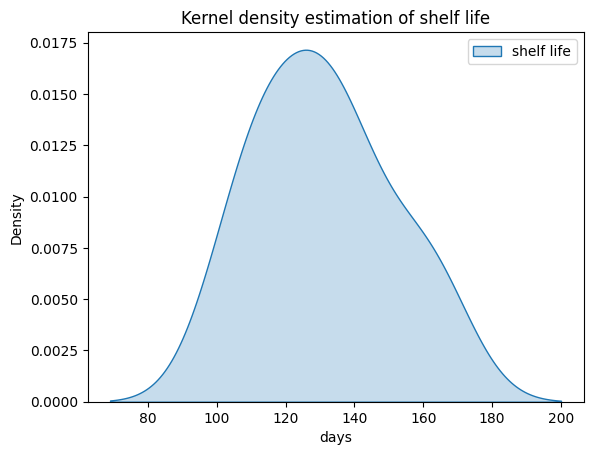

In [124]:
sns.kdeplot(df20['Days'], fill=True, label='shelf life')
plt.title('Kernel density estimation of shelf life')
plt.xlabel('days')
plt.legend()
plt.show()

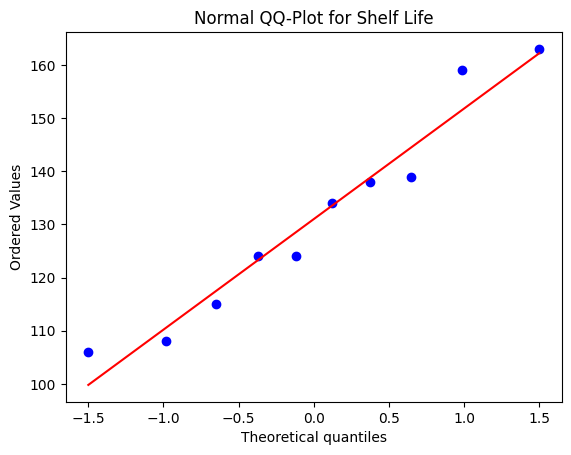

In [125]:
plt.figure()
stats.probplot(df20['Days'], dist="norm", plot=plt)
plt.title('Normal QQ-Plot for Shelf Life')
plt.show()

In [126]:
statistic_shap, p_value_shap = shapiro(df20['Days'])

print(f'Shapiro-Wilk Test for shelf life of a carbonated beverage: Statistic={statistic_shap:.4f}, p-value={p_value_shap:.4f}.')
print('KDE, QQ-plot and Shapiro-Wilk test suggest that shelf life can be modelled using Normal distribution.')

Shapiro-Wilk Test for shelf life of a carbonated beverage: Statistic=0.9365, p-value=0.5152.
KDE, QQ-plot and Shapiro-Wilk test suggest that shelf life can be modelled using Normal distribution.


T-test assumes normality of data, so it is necessary to check this assumption. If data are not normal, we can use central limit theorem, however, in our case we have only 10 measurements, so this approach would fail.

### Exercise 2.21

In semiconductor manufacturing, wet chemical etching is often used to remove silicon from the backs of wafers prior to metallization. The **etch rate** is an important characteristic of this process. Two different etching solutions are being evaluated. Eight randomly selected wafers have been etched in each solution and the observed etch rates (in mils/min) are shown below:

| Solution 1 | Solution 2 |
|------------|------------|
|  9.9       | 10.2       |
|  9.4       | 10.0       |
| 10.0       | 10.7       |
| 10.3       | 10.5       |
| 10.6       | 10.6       |
| 10.3       | 10.2       |
|  9.3       | 10.4       |
|  9.8       | 10.3       |

**(a)** Do the data indicate that the claim that both solutions have the same mean etch rate is valid? Use α = 0.05 and assume equal variances.  

**(b)** Find a 95% confidence interval on the difference in mean etch rates.  

**(c)** Use normal probability plots to investigate the adequacy of the assumptions of normality and equal variances.  

**(d)** Compute the power of the test in part (a). Assume that the true difference in means and the common variance equal the estimates obtained from the data. How many observations per group would be required to achieve power greater than 0.9 to detect a difference of Δ = 0.3 at significance level α = 0.05?


In [127]:
# Read the data from the URL
url_21 = "https://raw.githubusercontent.com/francji1/01NAEX/main/data/Ex02_21.csv"
df21 = pd.read_csv(url_21, sep=";")

# Display the first few rows of the dataframe
df21.head()

,Solution1,Solution2
0,9.9,10.2
1,9.4,10.0
2,10.0,10.7
3,10.3,10.5
4,10.6,10.6


**Solution:**

In [128]:
alpha = 0.05

t_stat_equal_var, p_value_equal_var = stats.ttest_ind(df21['Solution1'], df21['Solution2'], equal_var=True)

if p_value_equal_var < alpha:
    print(f"Since the p-value {p_value_equal_var:.4f} is less than alpha {alpha}, solutions' mean etch rates are not equal.")
else:
    print(f"Since the p-value {p_value_equal_var:.4f} is greater than alpha {alpha}, solutions' mean etch rates are equal.")

Since the p-value 0.0372 is less than alpha 0.05, solutions' mean etch rates are not equal.


In [129]:
n1, n2 = len(df21['Solution1']), len(df21['Solution2'])

mean_diff = np.mean(df21['Solution1']) - np.mean(df21['Solution2'])

pooled_std = np.sqrt(((n1 - 1) * np.var(df21['Solution1'], ddof=1) + (n2 - 1) * np.var(df21['Solution2'], ddof=1)) / (n1 + n2 - 2))

se_pooled = pooled_std * np.sqrt(1/n1 + 1/n2)

conf_interval_equal_var = stats.t.interval(0.95, df=n1 + n2 - 2, loc=mean_diff, scale=se_pooled)
print(f'{(1-alpha)*100}% confidence interval for the difference in mean etch rates is: ({conf_interval_equal_var[0]:.4f}; {conf_interval_equal_var[1]:.4f}).')

95.0% confidence interval for the difference in mean etch rates is: (-0.7969; -0.0281).


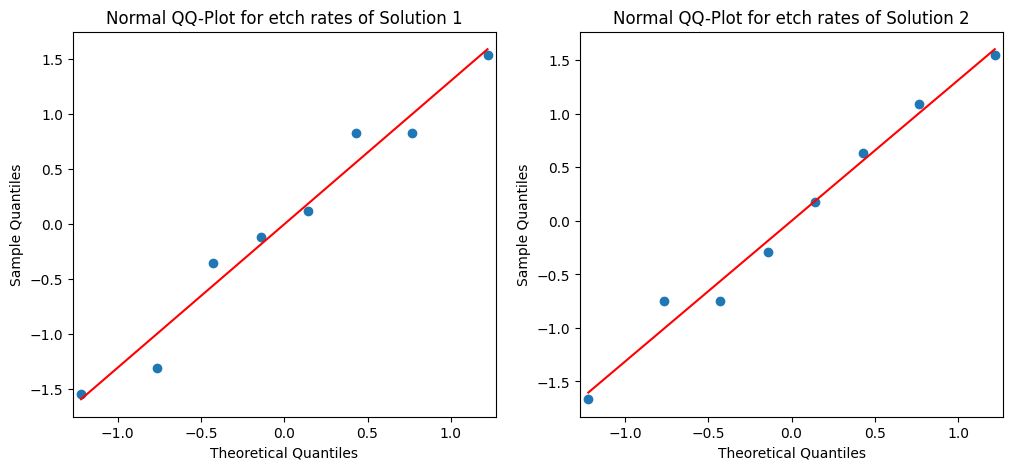

In [130]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,5))
sm.qqplot(dist = stats.distributions.norm, ax=ax1, fit=True, line = 'r', data=df21['Solution1'])
sm.qqplot(dist = stats.distributions.norm, ax=ax2, fit=True, line = 'r', data=df21['Solution2'])
ax1.set_title('Normal QQ-Plot for etch rates of Solution 1')
ax2.set_title('Normal QQ-Plot for etch rates of Solution 2')
plt.show()

In [131]:
# Parameters
s1_squared = np.var(df21['Solution1'], ddof=1)
s2_squared = np.var(df21['Solution2'], ddof=1)

difference = 0.3
effect_size1 = mean_diff / np.sqrt((s1_squared + s2_squared) / 2)
effect_size2 = difference / np.sqrt((s1_squared + s2_squared) / 2)
alpha = 0.05
power = 0.90

actual_power = analysis.power(effect_size=effect_size1, nobs1=len(df21['Solution1']), alpha=alpha, alternative='two-sided')
print(f'Power of the test with n={len(df21['Solution1'])} per group: {actual_power:.4f}.')

# Calculate required sample size
sample_size = analysis.solve_power(effect_size=effect_size2, alpha=alpha, power=power, alternative='two-sided')
print(f'Required sample size per group to achieve power greater than 0.9 and to detect a difference of Δ = 0.3 at significance level α = 0.05: {np.ceil(sample_size)}.')

Power of the test with n=8 per group: 0.5724.
Required sample size per group to achieve power greater than 0.9 and to detect a difference of Δ = 0.3 at significance level α = 0.05: 31.0.



### Exercise 2.26

The following are the burning times (in minutes) of chemical flares of two different formulations. The design engineers are interested in both the mean and
variance of the burning times.

|Type1|   | Type2 | |
|----|----|----|----|
| 65 | 82 | 64 | 56 |
| 81 | 67 | 71 | 69 |
| 57 | 59 | 83 | 74 |
| 66 | 75 | 59 | 82 |
| 82 | 70 | 65 | 79 |


1. Test the hypothesis that the two variances are equal. Use $\alpha = 0.05$.
2. Using the results of part 1), test the hypothesis that the mean burning
times are equal. Use $\alpha = 0.05$. What is the P-value for this test?
3. Discuss the role of the normality assumption in this problem. Check the
assumption of normality for both types of flares
4. If the mean burning times of the two flares differ by as much as 2 minutes, find the power of the test. What sample size would be required to detect an actual difference in mean burning time of 1 minute with a power of at least 0.9?

In [132]:
# Read the data from the URL
url_26 = "https://raw.githubusercontent.com/francji1/01NAEX/main/data/Ex02_26.csv"
df26 = pd.read_csv(url_26, sep=";")

# Display the first few rows of the dataframe
df26.head()

,Type1,Type2
0,65,64
1,81,71
2,57,83
3,66,59
4,82,65


**Solution:**

$H_0:\sigma_1^2=\sigma_2^2$ vs. $H_1:\sigma_1^2\neq\sigma_2^2$

In [133]:
# Sample variances
alpha = 0.05

s1_squared = np.var(df26['Type1'], ddof=1)
s2_squared = np.var(df26['Type2'], ddof=1)

# Degrees of freedom
dfn = len(df26['Type1']) - 1  # Degrees of freedom numerator
dfd = len(df26['Type2']) - 1  # Degrees of freedom denominator

# F-test statistic
F = s1_squared / s2_squared

# Two-tailed p-value
p_value = 2 * min(f.cdf(F, dfn, dfd), 1 - f.cdf(F, dfn, dfd))

if p_value < alpha:
    print(f"Since the p-value {p_value:.4f} is less than alpha {alpha}, we reject the null hypothesis.")
else:
    print(f"Since the p-value {p_value:.4f} is greater than alpha {alpha}, we fail to reject the null hypothesis.")

Since the p-value 0.9744 is greater than alpha 0.05, we fail to reject the null hypothesis.


$H_0:\mu_1=\mu_2$ vs. $H_1:\mu_1\neq\mu_2$

In [134]:
t_stat_equal_var, p_value_equal_var = stats.ttest_ind(df26['Type1'], df26['Type2'], equal_var=True)

if p_value_equal_var < alpha:
    print(f"Since the p-value {p_value_equal_var:.4f} is less than alpha {alpha}, we reject the null hypothesis.")
else:
    print(f"Since the p-value {p_value_equal_var:.4f} is greater than alpha {alpha}, we fail to reject the null hypothesis.")

Since the p-value 0.9622 is greater than alpha 0.05, we fail to reject the null hypothesis.


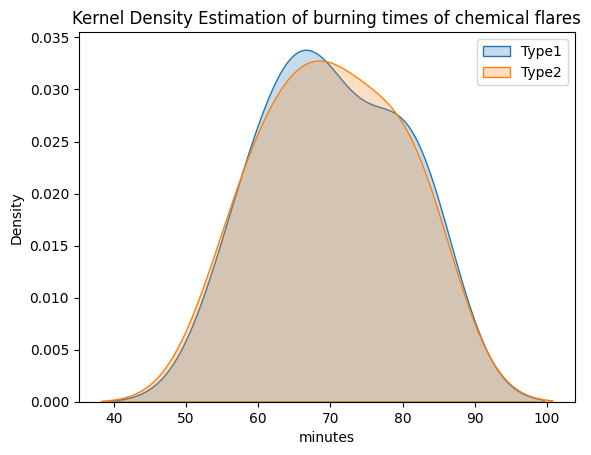

In [135]:
sns.kdeplot(df26['Type1'], fill=True, label='Type1')
sns.kdeplot(df26['Type2'], fill=True, label='Type2')
plt.title('Kernel Density Estimation of burning times of chemical flares')
plt.xlabel('minutes')
plt.legend()
plt.show()

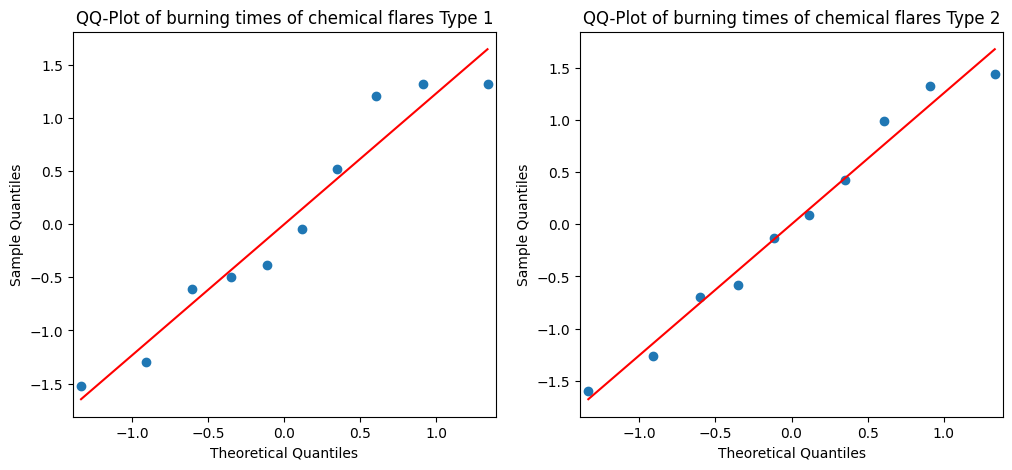

In [136]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,5))
sm.qqplot(dist = stats.distributions.norm, ax=ax1, fit=True, line = 'r', data=df26['Type1'])
sm.qqplot(dist = stats.distributions.norm, ax=ax2, fit=True, line = 'r', data=df26['Type2'])
ax1.set_title('QQ-Plot of burning times of chemical flares Type 1')
ax2.set_title('QQ-Plot of burning times of chemical flares Type 2')
plt.show()

In [137]:
statistic_shap, p_value_shap = shapiro(df26['Type1'])
print(f'Shapiro-Wilk Test for burning times of chemical flares Type 1: Statistic={statistic_shap:.4f}, p-value={p_value_shap:.4f}.')
statistic_shap, p_value_shap = shapiro(df26['Type2'])
print(f'Shapiro-Wilk Test for burning times of chemical flares Type 2: Statistic={statistic_shap:.4f}, p-value={p_value_shap:.4f}.')

Shapiro-Wilk Test for burning times of chemical flares Type 1: Statistic=0.9136, p-value=0.3065.
Shapiro-Wilk Test for burning times of chemical flares Type 2: Statistic=0.9548, p-value=0.7251.


Normality assumption is crucial for both F-test and t-test. Although the burning time is actually a positive random variable, according to KDE, QQ-plots and Shapiro-wilk tests we can model burning times using Normal distribution in both cases.

In [138]:
s1_squared = np.var(df26['Type1'], ddof=1)
s2_squared = np.var(df26['Type2'], ddof=1)

diff1 = 2
diff2 = 1

effect_size = diff1 / np.sqrt((s1_squared + s2_squared) / 2)
effect_size2 = diff2 / np.sqrt((s1_squared + s2_squared) / 2)
alpha = 0.05
power = 0.9

# Create an instance of the power analysis class
analysis = TTestIndPower()

actual_power = analysis.power(effect_size=effect_size, nobs1=len(df26['Type1']), alpha=alpha, alternative='two-sided')
print(f'Power of the test with n={len(df26['Type1'])} per group: {actual_power:.4f}.')

sample_size = analysis.solve_power(effect_size=effect_size2, alpha=alpha, power=power, alternative='two-sided')
print(f'Required sample size per group to detect an actual difference in mean burning time of 1 minute with a power of at least 0.9: {np.ceil(sample_size)}.')

Power of the test with n=10 per group: 0.0740.
Required sample size per group to detect an actual difference in mean burning time of 1 minute with a power of at least 0.9: 1825.0.


### Exercise 2.30

Front housings for cell phones are manufactured in an injection molding process. The time the part is allowed to cool in the mold before removal is thought to influence the occurrence of a particularly troublesome cosmetic defect, flow lines, in the finished housing. After manufacturing, the housings are inspected visually and assigned a score between 1 and 10 based on their appearance, with 10 corresponding to a perfect part and 1 corresponding to a completely defective part. An experiment was conducted using two cool-down times, 10 and 20 seconds, and 20 housings were evaluated at each level of cool-down time. All 40 observations in this experiment were run in random order.

Cool-down time 10 seconds:

| | | | |
|---|---|---|---|
| 1 | 3 | 2 | 6 |
| 1 | 5 | 3 | 3 |
| 5 | 2 | 1 | 1 |
| 5 | 6 | 2 | 8 |
| 3 | 2 | 5 | 3 |

Cool-down time 20 seconds:

| | | | |
|---|---|---|---|
| 7 | 6 | 8 | 9 |
| 5 | 5 | 9 | 7 |
| 5 | 4 | 8 | 6 |
| 6 | 8 | 4 | 5 |
| 6 | 8 | 7 | 7 |

* Is there evidence to support the claim that the longer cool-down time results in fewer appearance defects? Use $\alpha = 0.05$.
* What is the P-value for the test conducted in the previous part?
* Find a 95 percent confidence interval on the difference in means. Provide a practical interpretation of this interval.
* Compute the power of the test.

In [139]:
# Read the data from the URL
url_30 = "https://raw.githubusercontent.com/francji1/01NAEX/main/data/Ex02_30.csv"
df30 = pd.read_csv(url_30, sep=";")

# Display the first few rows of the dataframe
df30.head()

,10 seconds,20 seconds
0,1,7
1,2,8
2,1,5
3,3,9
4,5,5


**Solution:**

$H_0:\sigma_1^2=\sigma_2^2$ vs. $H_1:\sigma_1^2\neq\sigma_2^2$

In [140]:
alpha=0.05

s1_squared = np.var(df30['10 seconds'], ddof=1)
s2_squared = np.var(df30['20 seconds'], ddof=1)

# Degrees of freedom
dfn = len(df30['10 seconds']) - 1  # Degrees of freedom numerator
dfd = len(df30['20 seconds']) - 1  # Degrees of freedom denominator

# F-test statistic
F = s1_squared / s2_squared

# Two-tailed p-value
p_value = 2 * min(f.cdf(F, dfn, dfd), 1 - f.cdf(F, dfn, dfd))

if p_value < alpha:
    print(f"Since the p-value {p_value:.4f} is less than alpha {alpha}, we reject the null hypothesis.")
else:
    print(f"Since the p-value {p_value:.4f} is greater than alpha {alpha}, we fail to reject the null hypothesis.")

Since the p-value 0.2559 is greater than alpha 0.05, we fail to reject the null hypothesis.


In [141]:
#normality check
statistic_shap, p_value_shap = shapiro(df30['10 seconds'])
print(f'Shapiro-Wilk Test for 10s cool-down: Statistic={statistic_shap:.4f}, p-value={p_value_shap:.4f}.')
statistic_shap, p_value_shap = shapiro(df30['20 seconds'])
print(f'Shapiro-Wilk Test for 20s cool-down: Statistic={statistic_shap:.4f}, p-value={p_value_shap:.4f}.')

Shapiro-Wilk Test for 10s cool-down: Statistic=0.9034, p-value=0.0479.
Shapiro-Wilk Test for 20s cool-down: Statistic=0.9398, p-value=0.2379.


In spite of the p-value$<0.05$ in the first case, we will proceed to the classic t-test.

In [142]:
t_stat_equal_var, p_value_equal_var = stats.ttest_ind(df30['10 seconds'], df30['20 seconds'], equal_var=True, alternative='less')

if p_value_equal_var < alpha:
    print(f"Since the p-value {p_value_equal_var:.6f} is less than alpha {alpha}, we reject the null hypothesis.")
else:
    print(f"Since the p-value {p_value_equal_var:.6f} is greater than alpha {alpha}, we fail to reject the null hypothesis.")

Since the p-value 0.000001 is less than alpha 0.05, we reject the null hypothesis.


In [143]:
n1, n2 = len(df30['10 seconds']), len(df30['20 seconds'])
mean_diff = np.mean(df30['10 seconds']) - np.mean(df30['20 seconds'])
pooled_std = np.sqrt(((n1 - 1) * np.var(df30['10 seconds'], ddof=1) + (n2 - 1) * np.var(df30['20 seconds'], ddof=1)) / (n1 + n2 - 2))

se_pooled = pooled_std * np.sqrt(1/n1 + 1/n2)
conf_interval_equal_var = stats.t.interval(0.95, df=n1 + n2 - 2, loc=mean_diff, scale=se_pooled)
print(f'{(1-alpha)*100}% confidence interval for the difference in mean appearance defects is: ({conf_interval_equal_var[0]:.1f}; {conf_interval_equal_var[1]:.1f}).')

95.0% confidence interval for the difference in mean appearance defects is: (-4.3; -2.0).


With the probability of 95% true mean score after 10s cool-down is 2-4.3 points less than after 20s cool-down.

In [144]:
effect_size = (np.mean(df30['10 seconds']) - np.mean(df30['20 seconds'])) / np.sqrt((s1_squared + s2_squared) / 2)
alpha = 0.05

actual_power = analysis.power(effect_size=effect_size, nobs1=len(df30['10 seconds']), alpha=alpha, alternative='smaller')
print(f'Power of the test with n={len(df30['10 seconds'])} per group: {actual_power}')

Power of the test with n=20 per group: 0.999933954671495
